In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %% Imports
from jax import random, jit, numpy as jnp
from typing import Sequence
import jax

import matplotlib.pyplot as plt
from modax.data.burgers import burgers
from modax.training import mask_scheduler, create_stateful_update, Logger
from modax.layers import MaskedLeastSquares
from modax.feature_generators import library_backward
from modax.models.networks import MLP
from modax.losses.utils import mse
from modax.training.convergence import Convergence

from flax import optim, linen as nn
from flax.core import freeze
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
# %% Imports
from modax.data.kdv import DoubleSoliton
from modax.models import DeepmodBayes
from modax.linear_model.mask_estimator import ThresholdedLasso
from flax import optim

from modax.losses.utils import normal_LL, gamma_LL, precision

In [4]:
class CustomModel(nn.Module):
    """Simple feed-forward NN."""

    features: Sequence[int]

    @nn.compact
    def __call__(self, inputs):
        prediction, dt, theta = library_backward(MLP(self.features), inputs)
        coeffs = MaskedLeastSquares()((dt, theta))
        return prediction, dt, theta, coeffs

In [5]:
def custom_loss_fn(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = MSE
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))


In [6]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-10, 10, 100)
t = jnp.linspace(0.1, 1.0, 10)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")

u = DoubleSoliton(x_grid, t_grid, c=[5.0, 2.0], x0=[0.0, -5.0])

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.2 * jnp.std(y) * random.normal(key, y.shape)

y = y / jnp.std(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [9]:
update = create_stateful_update(custom_loss_fn, model=model, x=X_train, y=y_train)
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [10]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()


Loss step 0.0: 1.3331612348556519
Loss step 1000.0: 0.03901853784918785
Loss step 2000.0: 0.03453833609819412


In [10]:
variables = {"params": optimizer.target, **state}
prediction, _, _, coeffs = model.apply(variables, X, mutable=list(state.keys()))[0]
prediction = prediction.reshape(x_grid.shape)

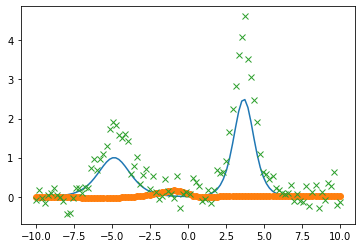

In [11]:
frame = 5
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

now let's calculate the gradients with respect to each loss:

In [12]:
from jax import value_and_grad

In [17]:
def mse_loss(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    
    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = MSE
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))

def pinn_loss(params, state, l, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = l[0] * MSE + l[1] * Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs, "w_mse": l[0], "w_reg": l[1]}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))


def reg_loss(params, state, model, x, y):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )
    

    MSE = mse(prediction, y)
    Reg = mse(dt.squeeze(), (theta @ coeffs).squeeze())
    loss = Reg
    metrics = {"loss": loss, "mse": MSE, "reg": Reg, "coeff": coeffs}

    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs))


In [18]:
grad_fn = value_and_grad(mse_loss, argnums=0, has_aux=True)
(loss, (updated_state, metrics, output)), grad = grad_fn(
    optimizer.target, state, model, X_train, y_train)

mse_grad = grad

In [19]:
grad_fn = value_and_grad(pinn_loss, argnums=0, has_aux=True)
(loss, (updated_state, metrics, output)), grad = grad_fn(
    optimizer.target, state, (1/2, 1/2), model, X_train, y_train)

pinn_grad = grad

In [20]:
grad_fn = value_and_grad(reg_loss, argnums=0, has_aux=True)
(loss, (updated_state, metrics, output)), grad = grad_fn(
    optimizer.target, state, model, X_train, y_train)

reg_grad = grad

In [23]:
import flax
from flax.core import unfreeze

In [24]:
mse_grads = jnp.concatenate([item.flatten() for key, item in flax.traverse_util.flatten_dict(unfreeze(mse_grad)).items()])[:, None]
reg_grads = jnp.concatenate([item.flatten() for key, item in flax.traverse_util.flatten_dict(unfreeze(reg_grad)).items()])[:, None]

In [27]:
alpha_optimal = ((reg_grads - mse_grads).T @ reg_grads) / jnp.linalg.norm(mse_grads - reg_grads)**2

In [28]:
alpha_optimal

DeviceArray([[-0.02444069]], dtype=float32)

In [29]:
jnp.linalg.norm(mse_grads - reg_grads)**2

DeviceArray(3.9750028, dtype=float32)

In [25]:
jnp.linalg.norm(mse_grads)

DeviceArray(2.0510342, dtype=float32)

In [26]:
jnp.linalg.norm(reg_grads)

DeviceArray(0.1934825, dtype=float32)

In [31]:
reg_grads

DeviceArray([[-0.00013112],
             [ 0.00012758],
             [-0.00045491],
             ...,
             [ 0.01996222],
             [ 0.02454815],
             [ 0.0116452 ]], dtype=float32)

In [32]:
reg_grads - mse_grads

DeviceArray([[-0.00293347],
             [ 0.00684004],
             [ 0.04799614],
             ...,
             [-0.08379661],
             [-0.16503866],
             [-0.01889536]], dtype=float32)

In [27]:
jnp.minimum(jnp.maximum(alpha_optimal.squeeze(), 0.0), 1.0)

DeviceArray(1., dtype=float32)

In [28]:
alpha_optimal = ((mse_grads - reg_grads).T @ mse_grads) / jnp.linalg.norm(reg_grads - mse_grads)**2

In [29]:
alpha_optimal

DeviceArray([[-0.00064793]], dtype=float32)

In [30]:
def create_stateful_update_pareto(*args, **kwargs):
    def step(opt, state,  *args, **kwargs):
        
        # Calculating optimal stuff
        grad_fn_mse = value_and_grad(mse_loss, argnums=0, has_aux=True)
        grad_fn_reg = value_and_grad(reg_loss, argnums=0, has_aux=True)
        mse_grad = grad_fn_mse(opt.target, state, *args, **kwargs)[1]
        reg_grad = grad_fn_reg(opt.target, state, *args, **kwargs)[1]
        mse_grads = jnp.concatenate([item.flatten() for key, item in flax.traverse_util.flatten_dict(unfreeze(mse_grad)).items()])[:, None]
        reg_grads = jnp.concatenate([item.flatten() for key, item in flax.traverse_util.flatten_dict(unfreeze(reg_grad)).items()])[:, None]
        alpha_optimal = (((reg_grads - mse_grads).T @ reg_grads) / jnp.linalg.norm(mse_grads - reg_grads)**2)
        

        alpha_optimal = jnp.minimum(jnp.maximum(alpha_optimal.squeeze(), 0.0), 1.0)
        
        l_mse = alpha_optimal   #/ jnp.linalg.norm(mse_grads)
        l_reg = 1-alpha_optimal #/ jnp.linalg.norm(reg_grads)
        
        grad_fn = value_and_grad(pinn_loss, argnums=0, has_aux=True)
        (loss, (updated_state, metrics, output)), grad = grad_fn(
            opt.target, state, (l_mse, l_reg), *args, **kwargs
        )
        metrics = {**metrics, 'alpha': alpha_optimal}
        opt = opt.apply_gradient(grad)  # Return the updated optimizer with parameters.

        return (opt, updated_state), metrics, output

    return jit(lambda opt, state: step(opt, state, *args, **kwargs))

In [35]:
# %% Building model and params
model = CustomModel([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

In [36]:
update = create_stateful_update_pareto(model=model, x=X_train, y=y_train)
validation_metric = jit(
    lambda opt, state: custom_loss_fn(opt.target, state, model, X_test, y_test)[1][1]
)
logger = Logger()
scheduler = mask_scheduler(delta=0.0, patience=1000)

In [ ]:
# Training till mse
max_epochs = 1e4
for epoch in jnp.arange(max_epochs):
    (optimizer, state), train_metrics, output = update(optimizer, state)
    prediction, dt, theta, coeffs = output

    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {train_metrics['loss']}")

    if epoch % 25 == 0:
        val_metrics = validation_metric(optimizer, state)
        metrics = {
            **train_metrics,
            "val_mse": val_metrics["mse"],
            "val_reg": val_metrics["reg"],
        }
        logger.write(metrics, epoch)

        apply_sparsity, optimizer = scheduler(val_metrics["mse"], epoch, optimizer)

        if apply_sparsity:
            break
logger.close()
